In [ ]:
import pandas as pd
df = pd.read_csv('/content/dataset-uci.csv')

In [ ]:
df.head()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [ ]:
df.columns

Index(['Gallstone Status', 'Age', 'Gender', 'Comorbidity',
       'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia',
       'Diabetes Mellitus (DM)', 'Height', 'Weight', 'Body Mass Index (BMI)',
       'Total Body Water (TBW)', 'Extracellular Water (ECW)',
       'Intracellular Water (ICW)',
       'Extracellular Fluid/Total Body Water (ECF/TBW)',
       'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)',
       'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)',
       'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)',
       'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)',
       'Visceral Muscle Area (VMA) (Kg)', 'Hepatic Fat Accumulation (HFA)',
       'Glucose', 'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)',
       'High Density Lipoprotein (HDL)', 'Triglyceride',
       'Aspartat Aminotransferaz (AST)', 'Alanin Aminotransferaz (ALT)',
       'Alkaline Phosphatase (ALP)', 'Creatinine',
       'Glomerular Filtration Rate (GFR

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, confusion_matrix, brier_score_loss
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay
from sklearn.manifold import TSNE
from sklearn.ensemble import HistGradientBoostingClassifier

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap

import warnings
warnings.filterwarnings('ignore')

Loading real dataset from /content/dataset-uci.csv...

--- Table 1: Dataset Characteristics ---


,Feature Classification,Feature,Gallstone (+),Gallstone (-),p-value
0,Demographics,Age,48.51 ± 11.20,47.63 ± 12.97,0.5173
1,Demographics,Gender,90 (57.0%),67 (41.6%),0.0086
2,Demographics,Comorbidity,0.31 ± 0.46,0.36 ± 0.57,0.3869
3,Demographics,Coronary Artery Disease (CAD),3 (1.9%),9 (5.6%),0.1504
4,Demographics,Hypothyroidism,3 (1.9%),6 (3.7%),0.5172
5,Demographics,Hyperlipidemia,8 (5.1%),0 (0.0%),0.0113
6,Demographics,Diabetes Mellitus (DM),27 (17.1%),16 (9.9%),0.0880
7,Demographics,Height,166.06 ± 10.25,168.23 ± 9.77,0.0543
8,Demographics,Weight,81.34 ± 15.44,79.81 ± 15.98,0.3861
9,Demographics,Body Mass Index (BMI),29.53 ± 5.27,28.24 ± 5.29,0.0300



--- Table 2: Model Performance + Calibration (Merged) ---


,Model,Accuracy,AUC,F1,Sensitivity,Specificity,Brier Score
0,XGBoost,0.782 ± 0.068,0.847 ± 0.064,0.776 ± 0.075,0.770 ± 0.106,0.794 ± 0.100,0.171 ± 0.051
1,LightGBM,0.780 ± 0.066,0.845 ± 0.063,0.774 ± 0.074,0.771 ± 0.106,0.788 ± 0.095,0.168 ± 0.047
2,CatBoost,0.794 ± 0.075,0.862 ± 0.061,0.785 ± 0.083,0.768 ± 0.109,0.819 ± 0.102,0.149 ± 0.037
3,HistGBM,0.781 ± 0.062,0.847 ± 0.065,0.774 ± 0.070,0.764 ± 0.101,0.798 ± 0.090,0.168 ± 0.047



--- Table 3: Feature Group Ablation Study ---


,Feature Set,AUC,F1,Accuracy
0,Demographics only,0.476 ± 0.097,0.468 ± 0.102,0.485 ± 0.087
1,Labs only,0.829 ± 0.070,0.749 ± 0.081,0.755 ± 0.075
2,Bioimpedance only,0.797 ± 0.079,0.706 ± 0.086,0.722 ± 0.075
3,Combined,0.847 ± 0.064,0.776 ± 0.075,0.782 ± 0.068


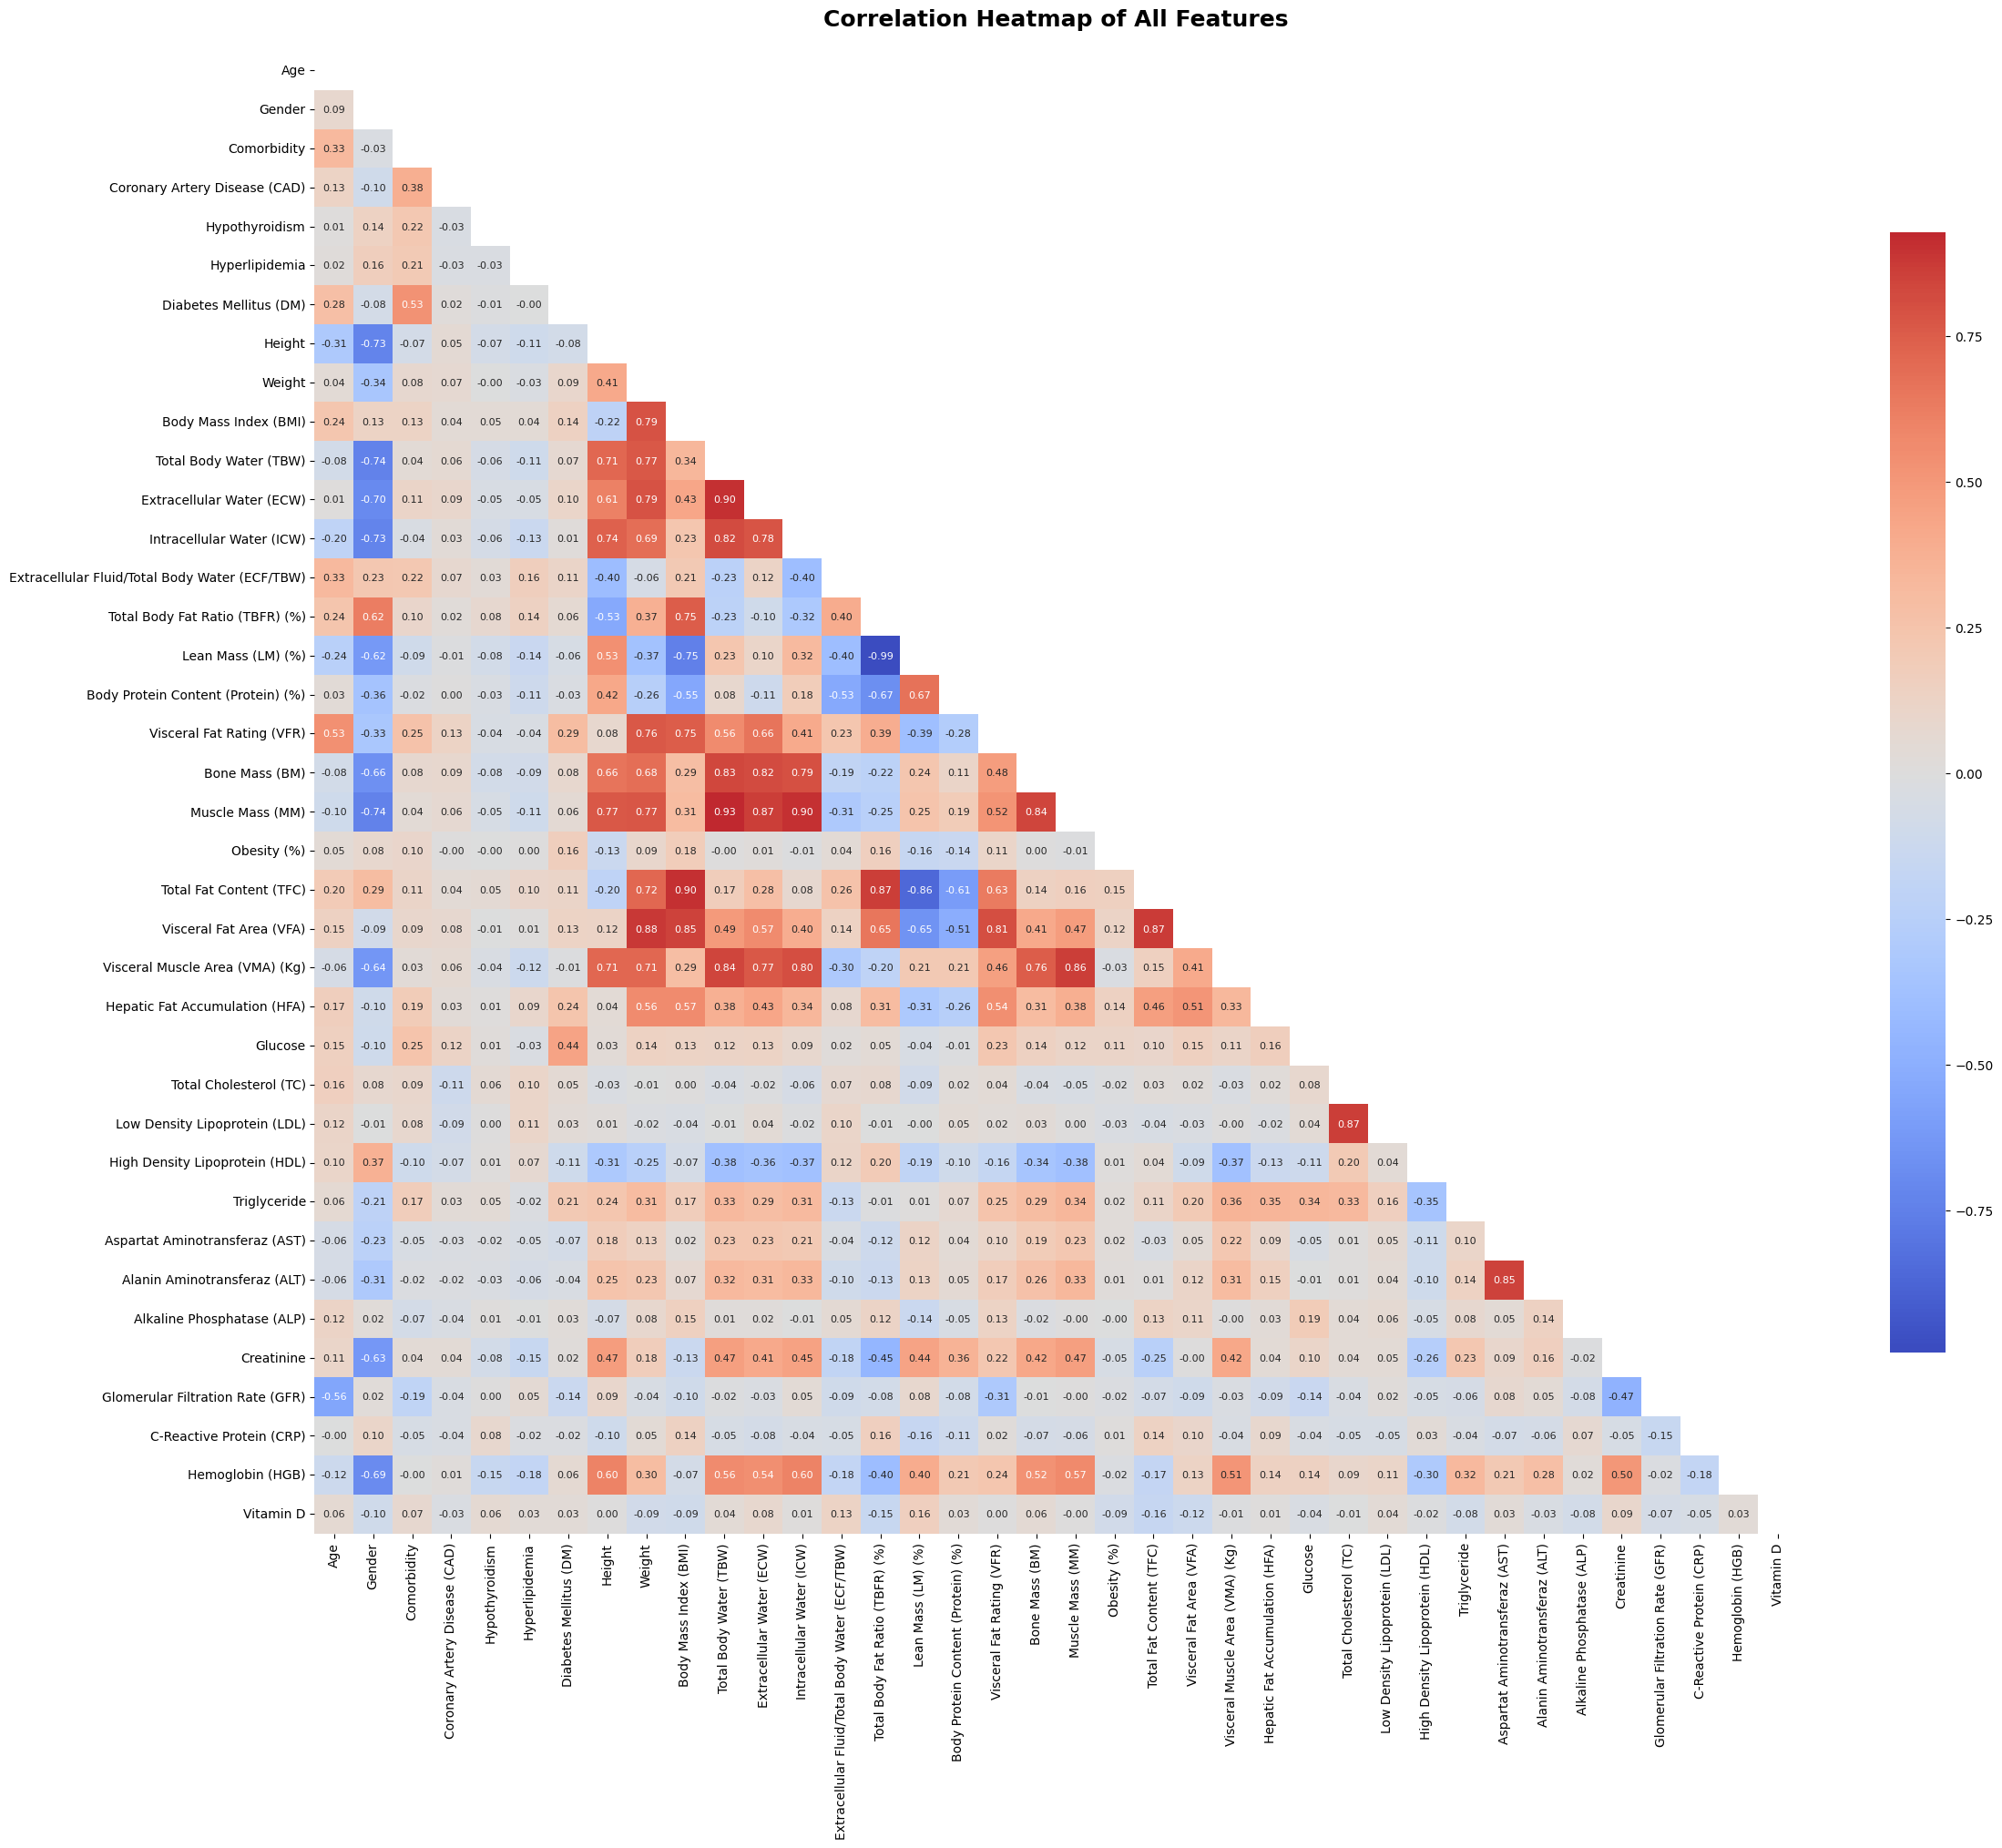

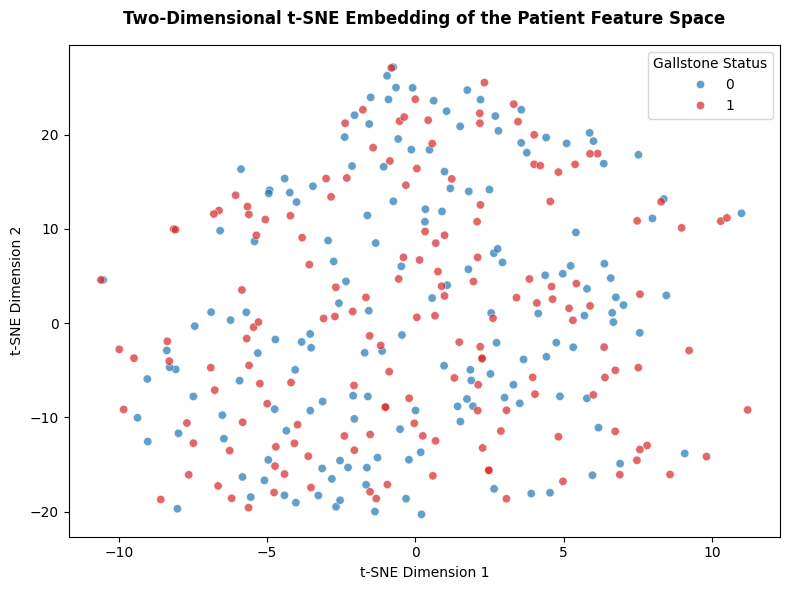

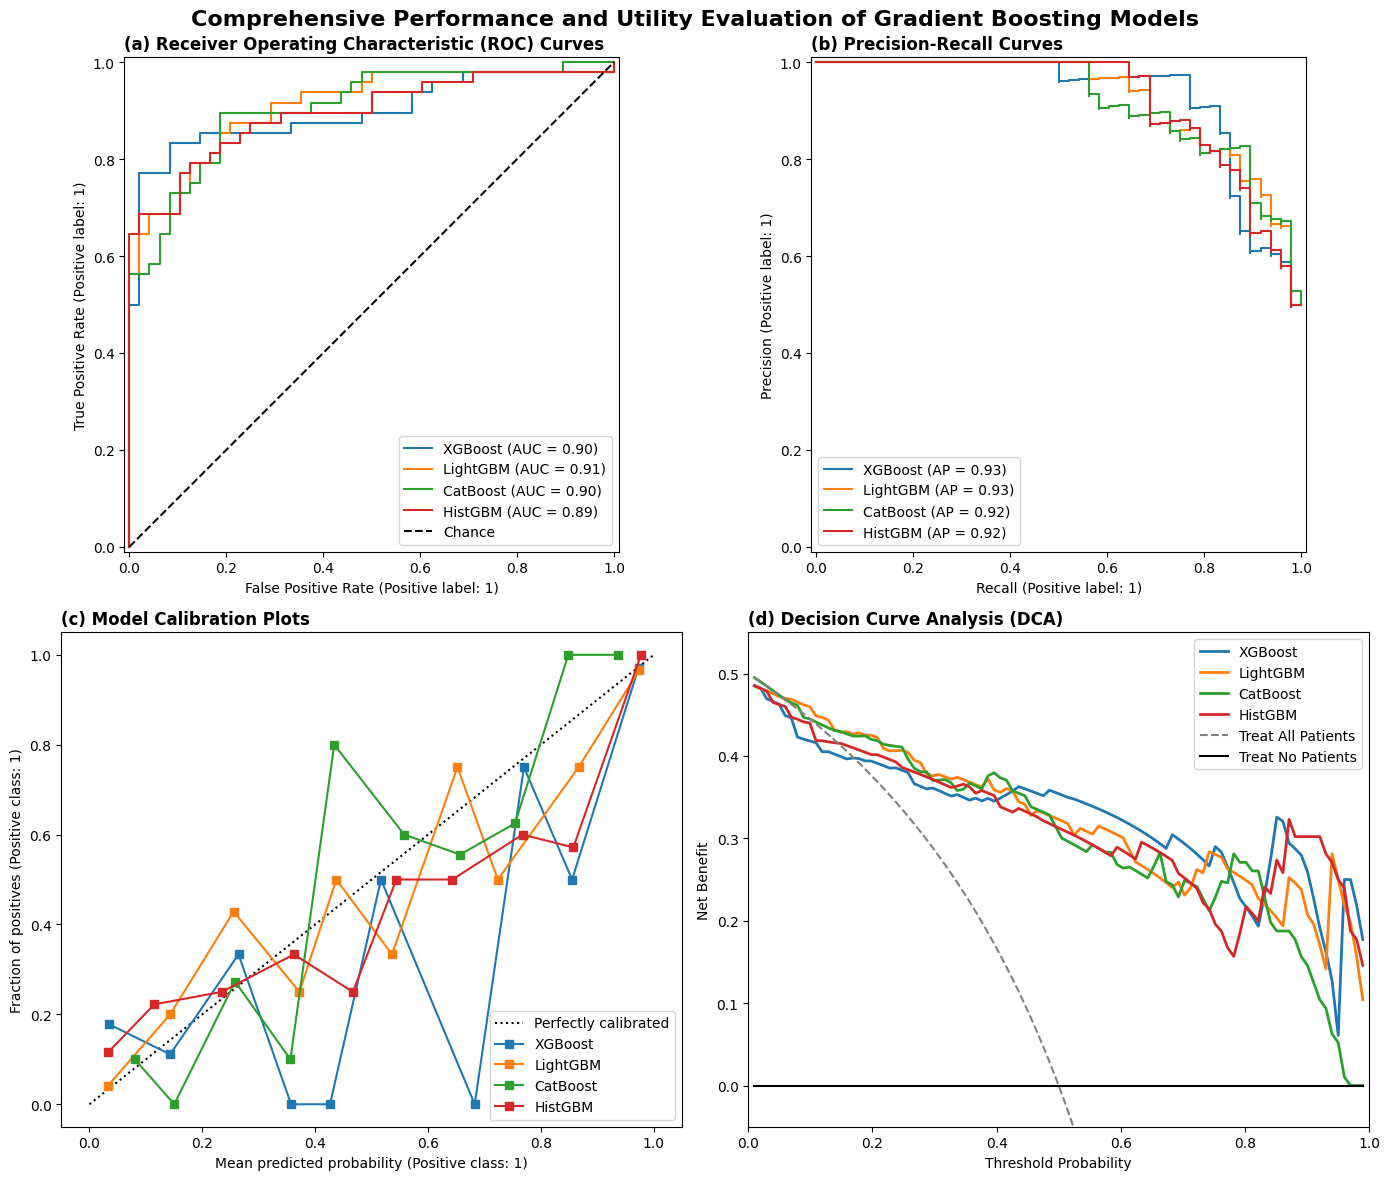

Calculating SHAP values for Figure 5...


PermutationExplainer explainer: 151it [00:47,  2.48it/s]


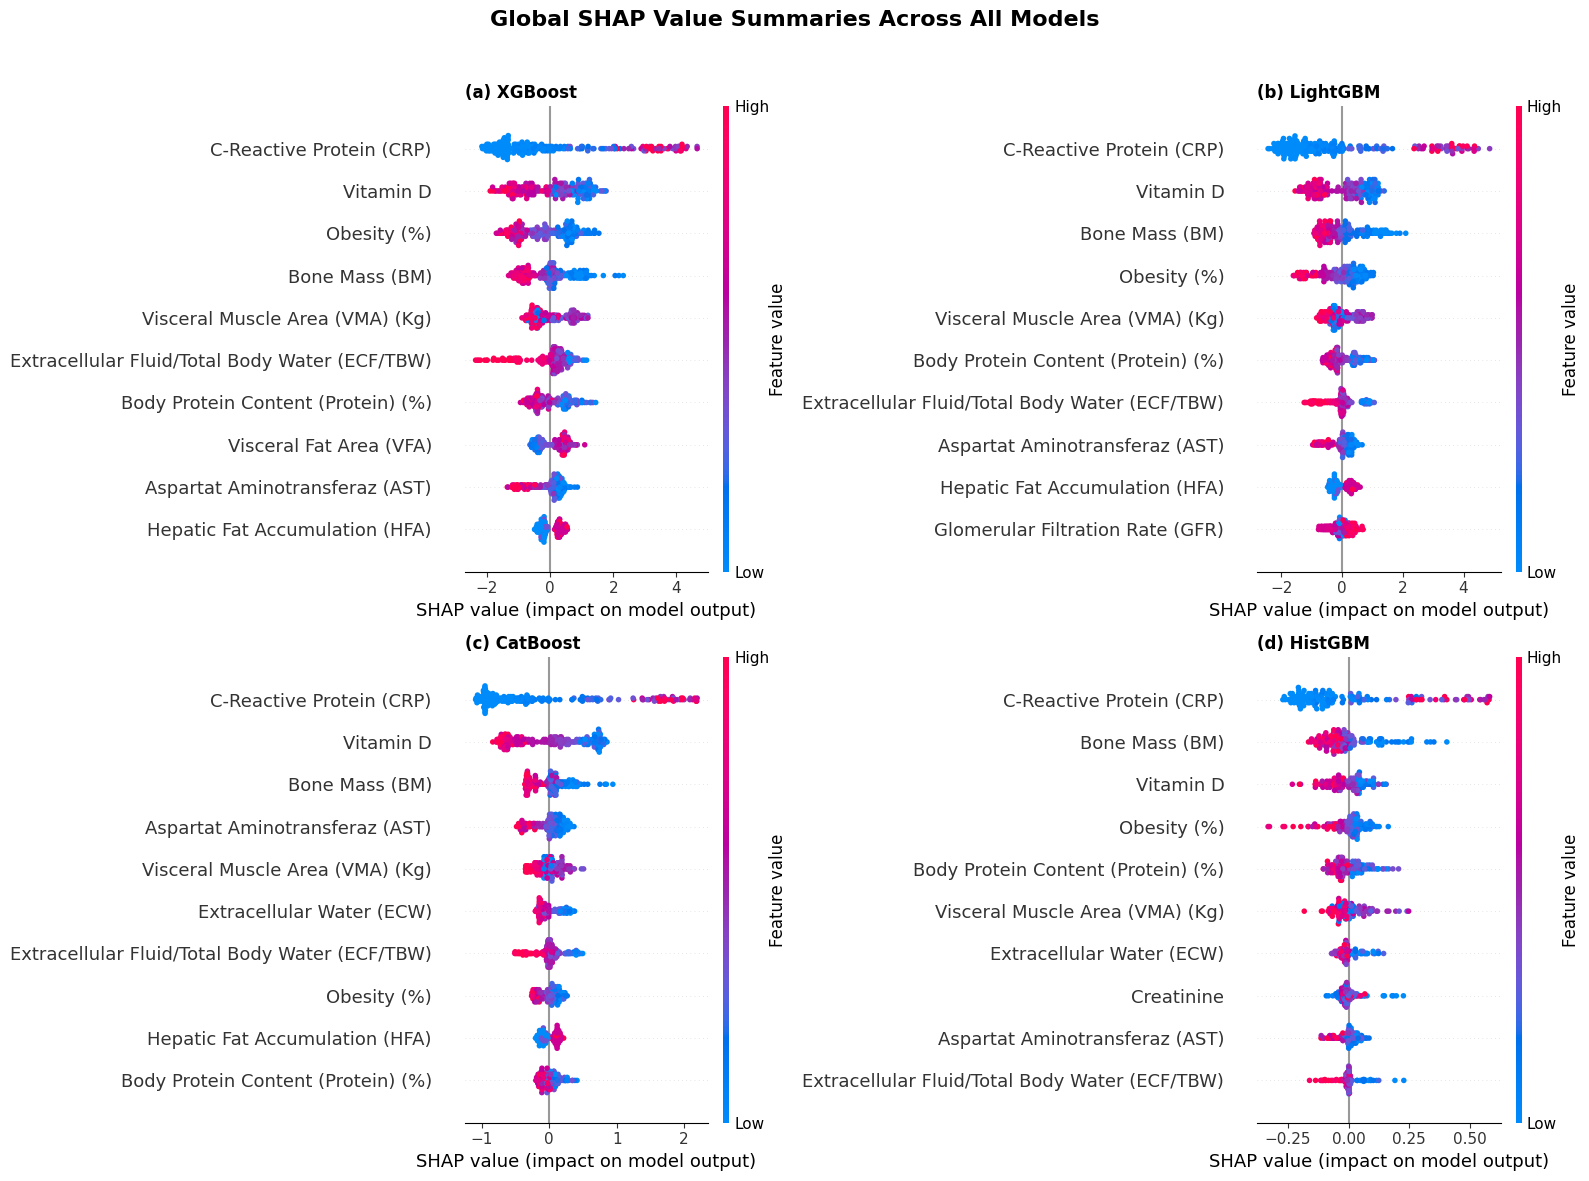

Calculating SHAP values for Figure 6...


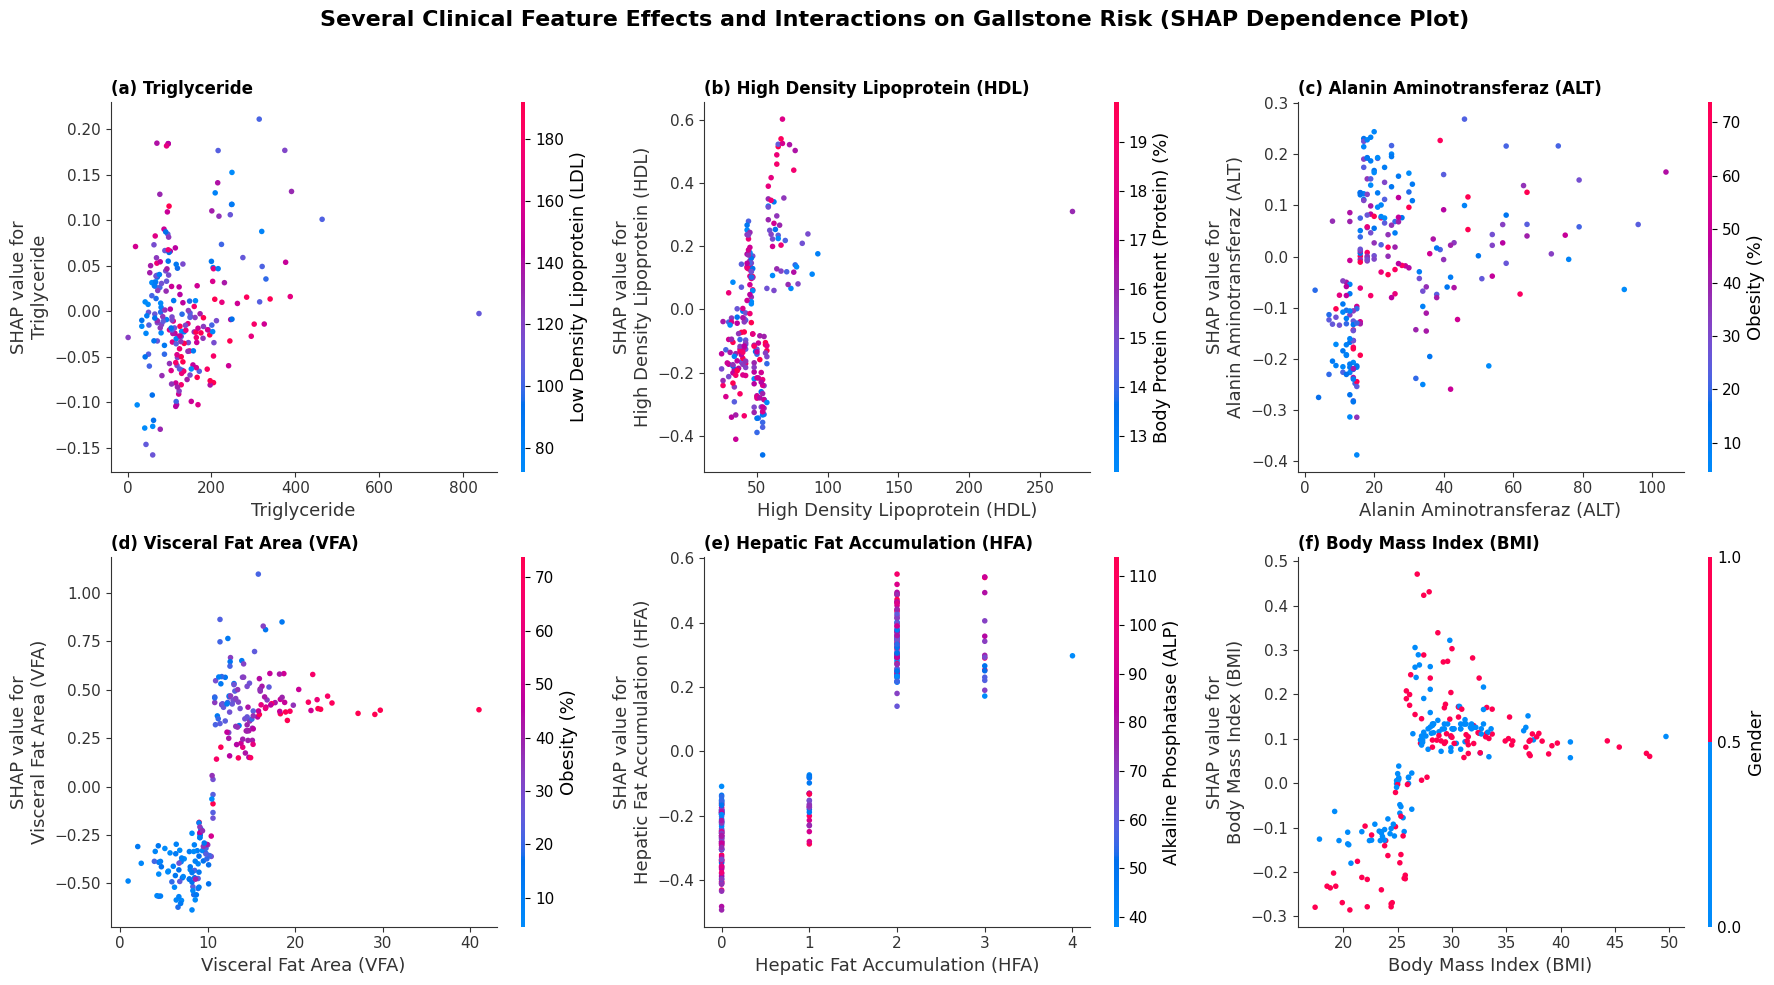

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, confusion_matrix, brier_score_loss
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.calibration import CalibrationDisplay
from sklearn.manifold import TSNE
from sklearn.ensemble import HistGradientBoostingClassifier

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap

import warnings
warnings.filterwarnings('ignore')

# Set plotting style for publication-ready figures
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10})

# =====================================================================
# 1. LOAD REAL DATASET & DEFINE FEATURES
# =====================================================================
print("Loading real dataset from /content/dataset-uci.csv...")
df = pd.read_csv('/content/dataset-uci.csv')

# Feature definitions based strictly on your PDF
feature_dict = {
    'Demographics': ['Age', 'Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)',
                     'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)',
                     'Height', 'Weight', 'Body Mass Index (BMI)'],
    'Bioimpedance': ['Total Body Water (TBW)', 'Extracellular Water (ECW)', 'Intracellular Water (ICW)',
                     'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat Ratio (TBFR) (%)',
                     'Lean Mass (LM) (%)', 'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)',
                     'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)', 'Total Fat Content (TFC)',
                     'Visceral Fat Area (VFA)', 'Visceral Muscle Area (VMA) (Kg)', 'Hepatic Fat Accumulation (HFA)'],
    'Labs': ['Glucose', 'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)',
             'High Density Lipoprotein (HDL)', 'Triglyceride', 'Aspartat Aminotransferaz (AST)',
             'Alanin Aminotransferaz (ALT)', 'Alkaline Phosphatase (ALP)', 'Creatinine',
             'Glomerular Filtration Rate (GFR)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']
}

all_features = feature_dict['Demographics'] + feature_dict['Bioimpedance'] + feature_dict['Labs']
target = 'Gallstone Status'

X = df[all_features]
y = df[target]

# =====================================================================
# TABLE 1: Dataset Characteristics
# =====================================================================
def create_table_1(df, feature_dict, target):
    rows = []
    df_pos = df[df[target] == 1]
    df_neg = df[df[target] == 0]

    for category, features in feature_dict.items():
        for feat in features:
            # Dynamically detect if a feature is binary (e.g., Gender, Comorbidities) or continuous
            is_binary = df[feat].dropna().nunique() <= 2

            if is_binary:
                # Categorical format: count (%)
                pos_val = f"{df_pos[feat].sum():.0f} ({df_pos[feat].mean()*100:.1f}%)"
                neg_val = f"{df_neg[feat].sum():.0f} ({df_neg[feat].mean()*100:.1f}%)"
                # Chi-Square test
                try:
                    _, p, _, _ = chi2_contingency(pd.crosstab(df[feat], df[target]))
                except:
                    p = 1.0 # Fallback if cross-tabulation fails
            else:
                # Continuous format: mean ± std
                pos_val = f"{df_pos[feat].mean():.2f} ± {df_pos[feat].std():.2f}"
                neg_val = f"{df_neg[feat].mean():.2f} ± {df_neg[feat].std():.2f}"
                # T-test
                _, p = ttest_ind(df_pos[feat].dropna(), df_neg[feat].dropna(), equal_var=False)

            rows.append({
                'Feature Classification': category,
                'Feature': feat,
                'Gallstone (+)': pos_val,
                'Gallstone (-)': neg_val,
                'p-value': f"{p:.4f}" if p >= 0.0001 else "<0.0001"
            })

    return pd.DataFrame(rows)

print("\n--- Table 1: Dataset Characteristics ---")
table1_df = create_table_1(df, feature_dict, target)
# Small font as requested in PDF
display(table1_df.style.set_properties(**{'font-size': '9pt'}))


# =====================================================================
# MODELING SETUP (For Tables 2 & 3 and Figures)
# =====================================================================
models = {
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, verbose=0),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': cb.CatBoostClassifier(random_state=42, verbose=0),
    'HistGBM': HistGradientBoostingClassifier(random_state=42)
}

def evaluate_models(X_data, y_data, models_dict, n_splits=10, n_repeats=10):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
    results = {m: {'acc':[], 'auc':[], 'f1':[], 'sens':[], 'spec':[], 'brier':[]} for m in models_dict.keys()}

    for train_idx, test_idx in rskf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        for name, model in models_dict.items():
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            y_prob = model.predict_proba(X_te)[:, 1]

            results[name]['acc'].append(accuracy_score(y_te, y_pred))
            results[name]['auc'].append(roc_auc_score(y_te, y_prob))
            results[name]['f1'].append(f1_score(y_te, y_pred))
            results[name]['sens'].append(recall_score(y_te, y_pred))
            tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
            results[name]['spec'].append(tn / (tn + fp))
            results[name]['brier'].append(brier_score_loss(y_te, y_prob))

    # Aggregate into mean ± std
    agg_results = []
    for name, metrics in results.items():
        agg_results.append({
            'Model': name,
            'Accuracy': f"{np.mean(metrics['acc']):.3f} ± {np.std(metrics['acc']):.3f}",
            'AUC': f"{np.mean(metrics['auc']):.3f} ± {np.std(metrics['auc']):.3f}",
            'F1': f"{np.mean(metrics['f1']):.3f} ± {np.std(metrics['f1']):.3f}",
            'Sensitivity': f"{np.mean(metrics['sens']):.3f} ± {np.std(metrics['sens']):.3f}",
            'Specificity': f"{np.mean(metrics['spec']):.3f} ± {np.std(metrics['spec']):.3f}",
            'Brier Score': f"{np.mean(metrics['brier']):.3f} ± {np.std(metrics['brier']):.3f}"
        })
    return pd.DataFrame(agg_results)

# =====================================================================
# TABLE 2: Model Performance + Calibration
# =====================================================================
print("\n--- Table 2: Model Performance + Calibration (Merged) ---")
table2_df = evaluate_models(X, y, models)
display(table2_df)


# =====================================================================
# TABLE 3: Feature Group Ablation Study
# =====================================================================
print("\n--- Table 3: Feature Group Ablation Study ---")
ablation_sets = {
    'Demographics only': feature_dict['Demographics'],
    'Labs only': feature_dict['Labs'],
    'Bioimpedance only': feature_dict['Bioimpedance'],
    'Combined': all_features
}

ablation_results = []
# Using XGBoost as the primary model to prove feature ablation
xgb_model = models['XGBoost']

for set_name, features_list in ablation_sets.items():
    X_sub = df[features_list]
    res = evaluate_models(X_sub, y, {'XGB': xgb_model})
    ablation_results.append({
        'Feature Set': set_name,
        'AUC': res['AUC'][0],
        'F1': res['F1'][0],
        'Accuracy': res['Accuracy'][0]
    })

table3_df = pd.DataFrame(ablation_results)
display(table3_df)


# =====================================================================
# FIGURE 2: Correlation Heatmap
# =====================================================================

plt.figure(figsize=(24, 20)) # Increased size for readability with numbers
corr_matrix = X.corr()

# Mask upper triangle to make it cleaner (optional but standard for papers)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            cmap='coolwarm',
            center=0,
            annot=True,          # Displays the numbers
            fmt=".2f",           # 2 decimal places
            annot_kws={"size": 8}, # Small font to fit cells
            cbar_kws={"shrink": .75},
            square=True)

plt.title("Correlation Heatmap of All Features", pad=20, fontsize=18)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


# =====================================================================
# FIGURE 3: t-SNE visualization
# =====================================================================
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette=['#1f77b4', '#d62728'], alpha=0.7)
plt.title("Two-Dimensional t-SNE Embedding of the Patient Feature Space", pad=15, fontweight='bold')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Gallstone Status')
plt.tight_layout()
plt.show()


# =====================================================================
# 2x2 PERFORMANCE PANEL (Multi-Model)
# =====================================================================
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Comprehensive Performance and Utility Evaluation of Gradient Boosting Models", fontsize=16)

def calculate_net_benefit(y_true, y_prob, pt_arr):
    net_benefits = []
    n = len(y_true)
    for pt in pt_arr:
        if pt == 1.0:
            net_benefits.append(0); continue
        preds = (y_prob >= pt).astype(int)
        tp = np.sum((preds == 1) & (y_true == 1))
        fp = np.sum((preds == 1) & (y_true == 0))
        nb = (tp / n) - (fp / n) * (pt / (1 - pt))
        net_benefits.append(nb)
    return net_benefits

thresholds = np.linspace(0.01, 0.99, 100)

# Loop through all models to plot them on the same subplots
for name, model in models.items():
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]

    # (A) ROC Curves
    RocCurveDisplay.from_predictions(y_te, y_prob, name=name, ax=axes[0,0])

    # (B) Precision-Recall Curves
    PrecisionRecallDisplay.from_predictions(y_te, y_prob, name=name, ax=axes[0,1])

    # (C) Calibration Curves
    CalibrationDisplay.from_predictions(y_te, y_prob, name=name, n_bins=10, ax=axes[1,0])

    # (D) Decision Curve Analysis (DCA)
    nb_model = calculate_net_benefit(y_te, y_prob, thresholds)
    axes[1,1].plot(thresholds, nb_model, label=name, linewidth=2)

# ---------------- Formatting Subplots ----------------

# (A) ROC Formatting
axes[0,0].plot([0, 1], [0, 1], 'k--', label='Chance')
axes[0,0].set_title("(a) Receiver Operating Characteristic (ROC) Curves", loc='left')
axes[0,0].legend(loc='lower right')

# (B) PR Formatting
axes[0,1].set_title("(b) Precision-Recall Curves", loc='left')
axes[0,1].legend(loc='lower left')

# (C) Calibration Formatting
axes[1,0].set_title("(c) Model Calibration Plots", loc='left')
axes[1,0].legend(loc='lower right')

# (D) DCA Formatting
nb_all = calculate_net_benefit(y_te, np.ones_like(y_te), thresholds)
axes[1,1].plot(thresholds, nb_all, label='Treat All Patients', linestyle='--', color='gray')
axes[1,1].plot(thresholds, np.zeros_like(thresholds), label='Treat No Patients', color='black')

# Set y-limit based on dataset prevalence for a clean DCA plot
prevalence = np.mean(y_te)
axes[1,1].set_ylim([-0.05, prevalence + 0.05])
axes[1,1].set_xlim([0, 1])
axes[1,1].set_xlabel('Threshold Probability')
axes[1,1].set_ylabel('Net Benefit')
axes[1,1].set_title("(d) Decision Curve Analysis (DCA)", loc='left')
axes[1,1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 5: SHAP Summary (Multi-model)
# =====================================================================
print("Calculating SHAP values for Figure 5...")
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Global SHAP Value Summaries Across All Models", fontsize=16, fontweight='bold')

model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'HistGBM']
labels = ['(a)', '(b)', '(c)', '(d)']

for i, m_name in enumerate(model_names):
    model = models[m_name]
    model.fit(X_tr, y_tr)

    # SHAP Explainer mapping based on model
    if m_name == 'HistGBM':
        # HistGBM requires a background dataset sample for Explainer
        explainer = shap.Explainer(model.predict, X_tr.sample(100, random_state=42))
        shap_values = explainer(X_tr.sample(150, random_state=42)).values
        shap_data = X_tr.sample(150, random_state=42)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_tr)
        shap_data = X_tr

        # Adjust if shap returns multi-class list format for binary targets
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

    ax = fig.add_subplot(2, 2, i+1)
    plt.sca(ax)
    shap.summary_plot(shap_values, shap_data, show=False, plot_size=None, max_display=10)
    ax.set_title(f"{labels[i]} {m_name}", loc='left', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# =====================================================================
# FIGURE 6: SHAP Dependence Plots
# =====================================================================
print("Calculating SHAP values for Figure 6...")
xgb_model = models['XGBoost']
xgb_model.fit(X_tr, y_tr)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_tr)

# Using exactly the mapping requested in your PDF
dep_features = [
    'Triglyceride',
    'High Density Lipoprotein (HDL)',
    'Alanin Aminotransferaz (ALT)',
    'Visceral Fat Area (VFA)',
    'Hepatic Fat Accumulation (HFA)',
    'Body Mass Index (BMI)'
]

dep_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

fig = plt.figure(figsize=(18, 10))
fig.suptitle("Several Clinical Feature Effects and Interactions on Gallstone Risk (SHAP Dependence Plot)", fontsize=16, fontweight='bold')

for i, feat in enumerate(dep_features):
    ax = fig.add_subplot(2, 3, i+1)
    shap.dependence_plot(feat, shap_values, X_tr, ax=ax, show=False)
    ax.set_title(f"{dep_labels[i]} {feat}", loc='left', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Stats analysis

In [ ]:
def evaluate_models_full(X_data, y_data, models_dict, n_splits=10, n_repeats=10):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    results = {m: {'auc': []} for m in models_dict.keys()}

    for train_idx, test_idx in rskf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        for name, model in models_dict.items():
            model.fit(X_tr, y_tr)
            y_prob = model.predict_proba(X_te)[:, 1]

            results[name]['auc'].append(roc_auc_score(y_te, y_prob))

    return results

In [ ]:
fold_results = evaluate_models_full(X, y, models)

In [ ]:
#STATISTICAL ANALYSIS

def evaluate_models_full(X_data, y_data, models_dict, n_splits=10, n_repeats=10):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    results = {m: {'auc': []} for m in models_dict.keys()}

    for train_idx, test_idx in rskf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        for name, model in models_dict.items():
            model.fit(X_tr, y_tr)
            y_prob = model.predict_proba(X_te)[:, 1]

            results[name]['auc'].append(roc_auc_score(y_te, y_prob))

    return results

fold_results = evaluate_models_full(X, y, models)

friedman_stat, friedman_p = friedmanchisquare(
    fold_results['XGBoost']['auc'],
    fold_results['LightGBM']['auc'],
    fold_results['CatBoost']['auc'],
    fold_results['HistGBM']['auc']
)

models_list = ['XGBoost', 'LightGBM', 'HistGBM']

rows = []

for m in models_list:
    diff = np.array(fold_results['CatBoost']['auc']) - np.array(fold_results[m]['auc'])

    stat, p = wilcoxon(
        fold_results['CatBoost']['auc'],
        fold_results[m]['auc']
    )

    rows.append({
        "Comparison": f"CatBoost vs {m}",
        "Median AUC Difference": np.median(diff),
        "Wilcoxon Statistic": stat,
        "p-value": p
    })

p_vals = [r["p-value"] for r in rows]
adjusted = [max(min(p * len(p_vals), 1.0), 1e-300) for p in p_vals]

for i in range(len(rows)):
    rows[i]["Adjusted p-value"] = adjusted[i]

table3_df = pd.DataFrame(rows)

friedman_row = pd.DataFrame([{
    "Comparison": "Friedman Test (All Models)",
    "Median AUC Difference": "-",
    "Wilcoxon Statistic": friedman_stat,
    "p-value": friedman_p,
    "Adjusted p-value": "-"
}])

table3_df = pd.concat([friedman_row, table3_df], ignore_index=True)

display(table3_df)

,Comparison,Median AUC Difference,Wilcoxon Statistic,p-value,Adjusted p-value
0,Friedman Test (All Models),-,40.527893,8.234588e-09,-
1,CatBoost vs XGBoost,0.015625,942.000000,4.039674e-07,0.000001
2,CatBoost vs LightGBM,0.019531,799.000000,3.772619e-08,0.0
3,CatBoost vs HistGBM,0.015625,851.500000,5.275918e-07,0.000002
